# **STEP 1: DATA CLEANING**

1.1 Importing Necessary Libraries

First of all, I will import all the necessary libraries that we will use throughout the project. This generally includes libraries for data manipulation, data visualization, and others based on the specific needs of the project:

In [57]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [58]:
# Configure Seaborn plot styles: Set background color and use dark grid
sns.set(rc={'axes.facecolor': '#fcf0dc'}, style='darkgrid')


In [59]:
# Initialize Plotly for use in the notebook
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

1.2 Loading the Dataset

Next, I will load the dataset into a pandas DataFrame which will facilitate easy manipulation and analysis:

In [60]:
df = pd.read_csv(r'shopping.csv',)

In [61]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


2.1 Dataset Overview


Afterward, I am going to gain a thorough understanding of the dataset before proceeding to the data cleaning and transformation stages.

Now, I am going to generate summary statistics to gain initial insights into the data distribution:

In [62]:
# Summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,1950.500000,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,44.068462,15.207589,18.0,31.00,44.0,57.00,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.00,60.0,81.00,100.0
Review Rating,3900.0,3.749949,0.716223,2.5,3.10,3.7,4.40,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.00,25.0,38.00,50.0


In [63]:
# Summary statistics for categorical variables
df.describe(include='object').T

,count,unique,top,freq
Gender,3900,2,Male,2652
Item Purchased,3900,25,Blouse,171
Category,3900,4,Clothing,1737
Location,3900,50,Montana,96
Size,3900,4,M,1755
Color,3900,25,Olive,177
Season,3900,4,Spring,999
Subscription Status,3900,2,No,2847
Shipping Type,3900,6,Free Shipping,675
Discount Applied,3900,2,No,2223


In [64]:
df.shape

(3900, 18)

2.2 Checking Missing Values

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [66]:
df.isnull()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3896,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3897,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3898,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


2.3 Duplicates

In [67]:
# Finding duplicate rows (keeping all instances)
duplicate_rows = df[df.duplicated(keep=False)]

# Sorting the data by certain columns to see the duplicate rows next to each other
duplicate_rows_sorted = duplicate_rows.sort_values(by=['Customer ID','Gender', 'Category'])

# Displaying the first 10 records
duplicate_rows_sorted.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases


In [68]:
# Displaying the number of duplicate rows
print(f"The dataset contains {df.duplicated().sum()} duplicate rows that need to be removed.")

# Removing duplicate rows
df.drop_duplicates(inplace=True)

The dataset contains 0 duplicate rows that need to be removed.


In [69]:
# Getting the number of rows in the dataframe
df.shape[0]

3900

2.4 Treat outliers

In K-means clustering, the algorithm is sensitive to both the scale of data and the presence of outliers, as they can significantly influence the position of centroids, potentially leading to incorrect cluster assignments.

In [70]:
def remove_outlier_IQR(df, series):
    Q1=df[series].quantile(0.25)
    Q3=df[series].quantile(0.75)
    IQR=Q3-Q1
    df_final=df[~((df[series]<(Q1-1.5*IQR)) | (df[series]>(Q3+1.5*IQR)))]
    return df_final

removed_outliers = df
columns_to_remove_outliers = ['Age','Purchase Amount (USD)', 'Previous Purchases', 'Review Rating', ]
for column in columns_to_remove_outliers:
    removed_outliers = remove_outlier_IQR(removed_outliers, column)

print("The final length of the dataset is", str(len(removed_outliers)), "rows.")

The final length of the dataset is 3900 rows.


Nếu muốn vẽ boxplot, tham khảo code "https://www.kaggle.com/code/pavankarthikchalla/customer-product-segmentation"


# **Step2: Exploratory Data Analysis**

Correlation matrix


In [71]:
df2 = df.copy()

In [72]:
df2['Gender'] = df['Gender'].map({'Female':0,'Male':1})
df2['Item Purchased'] = df['Item Purchased'].map({'Blouse':0,'Sweater':1,
                                                 'Jeans':2,'Sandals':3,
                                                 'Sneakers':4,'Shirt':5,
                                                 'Shorts':6,'Coat':7,
                                                 'Handbag':8,'Shoes':9,
                                                 'Dress':10,'Skirt':11,
                                                 'Sunglasses':12,'Pants':13,
                                                 'Jacket':14,'Hoodie':15,
                                                 'Jewelry':16,'T-shirt':17,
                                                 'Scarf':18,'Hat':19,
                                                 'Socks':20,'Backpack':21,
                                                 'Belt':22,'Boots':23, 'Gloves':24})
df2['Category'] = df['Category'].map({'Clothing':0,'Footwear':1,'Outerwear':2,'Accessories':3})
df2['Location'] = df['Location'].map({'Alabama': '0', 'Alaska': 1,'Arizona': 2,
        'Arkansas': 3,'California': 4,'Colorado': 5,'Connecticut': 6,
        'Delaware': 7,'District of Columbia': 8,'Florida': 9,'Georgia': 10,
        'Hawaii': 11,'Idaho': 12,'Illinois': 13,'Indiana': 14,'Iowa': 15,
        'Kansas': 16,'Kentucky': 17,'Louisiana': 18,'Maine': 19,
        'Maryland': 20,'Massachusetts': 21,'Michigan': 22,'Minnesota': 23,
        'Mississippi': 24,'Missouri': 25,'Montana': 26,'Nebraska': 27,
        'Nevada': 28,'New Hampshire': 29,'New Jersey': 30,'New Mexico': 31,
        'New York': 32,'North Carolina': 33,'North Dakota': 34,'Ohio': 35,
        'Oklahoma': 36,'Oregon': 37,'Pennsylvania': 38,'Rhode Island': 39,
        'South Carolina': 40,'South Dakota': 41,'Tennessee': 42,'Texas': 43,
        'Utah': 44,'Vermont': 45,'Virginia': 46,'Washington': 47,
        'West Virginia': 48,'Wisconsin': 49,'Wyoming':50})
df2['Size'] = df['Size'].map({'L':0,'M':1,'S':2,'XL':3})
df2['Color'] = df['Color'].map({'Gray':0,'Maroon':1,'Turquoise':2,'White':3,
                               'Charcoal':4,'Silver':5,'Pink':6,'Purple':7,
                               'Olive':8,'Gold':9,'Violet':10,'Teal':11,
                               'Lavender':12,'Black':13,'Green':14,'Peach':15,
                               'Red':16,'Cyan':17,'Brown':18,'Beige':19,
                               'Orange':20,'Indigo':21,'Yellow':22,'Magenta':23,
                               'Blue':24})
df2['Season'] = df['Season'].map({'Winter':0,'Spring':1,'Summer':2,'Fall':3})
df2['Subscription Status'] = df['Subscription Status'].map({'Yes':0,'No':1})
df2['Shipping Type'] = df['Shipping Type'].map({'Express':0,'Free Shipping':1,
                                               'Next Day Air':2,'Standard':3,
                                               '2-Day Shipping':4,'Store Pickup':5})
df2['Discount Applied'] = df['Discount Applied'].map({'Yes':0,'No':1})
df2['Promo Code Used'] = df['Promo Code Used'].map({'Yes':0,'No':1})
df2['Payment Method'] = df['Payment Method'].map({'Venmo':0,'Cash':1,
                                                 'Credit Card':2,'PayPal':3,
                                                 'Bank Transfer':4,
                                                 'Debit Card':5})
df2['Frequency of Purchases'] = df['Frequency of Purchases'].map({'Fortnightly':0,
                                                                 'Weekly':1,'Annually':2,
                                                                 'Quarterly':3,
                                                                 'Monthly':4,})
df2.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,1,0,0,53,17,0,0,0,3.1,0,0,0,0,14,0,0
1,2,19,1,1,0,64,19,0,1,0,3.1,0,0,0,0,2,1,0
2,3,50,1,2,0,73,21,2,1,1,3.1,0,1,0,0,23,2,1
3,4,21,1,3,1,90,39,1,1,1,3.5,0,2,0,0,49,3,1
4,5,45,1,0,0,49,37,1,2,1,2.7,0,1,0,0,31,3,2


In [73]:
#Corr()
shopping_new = df2 [[ 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases']]

shopping_corr = shopping_new.corr()


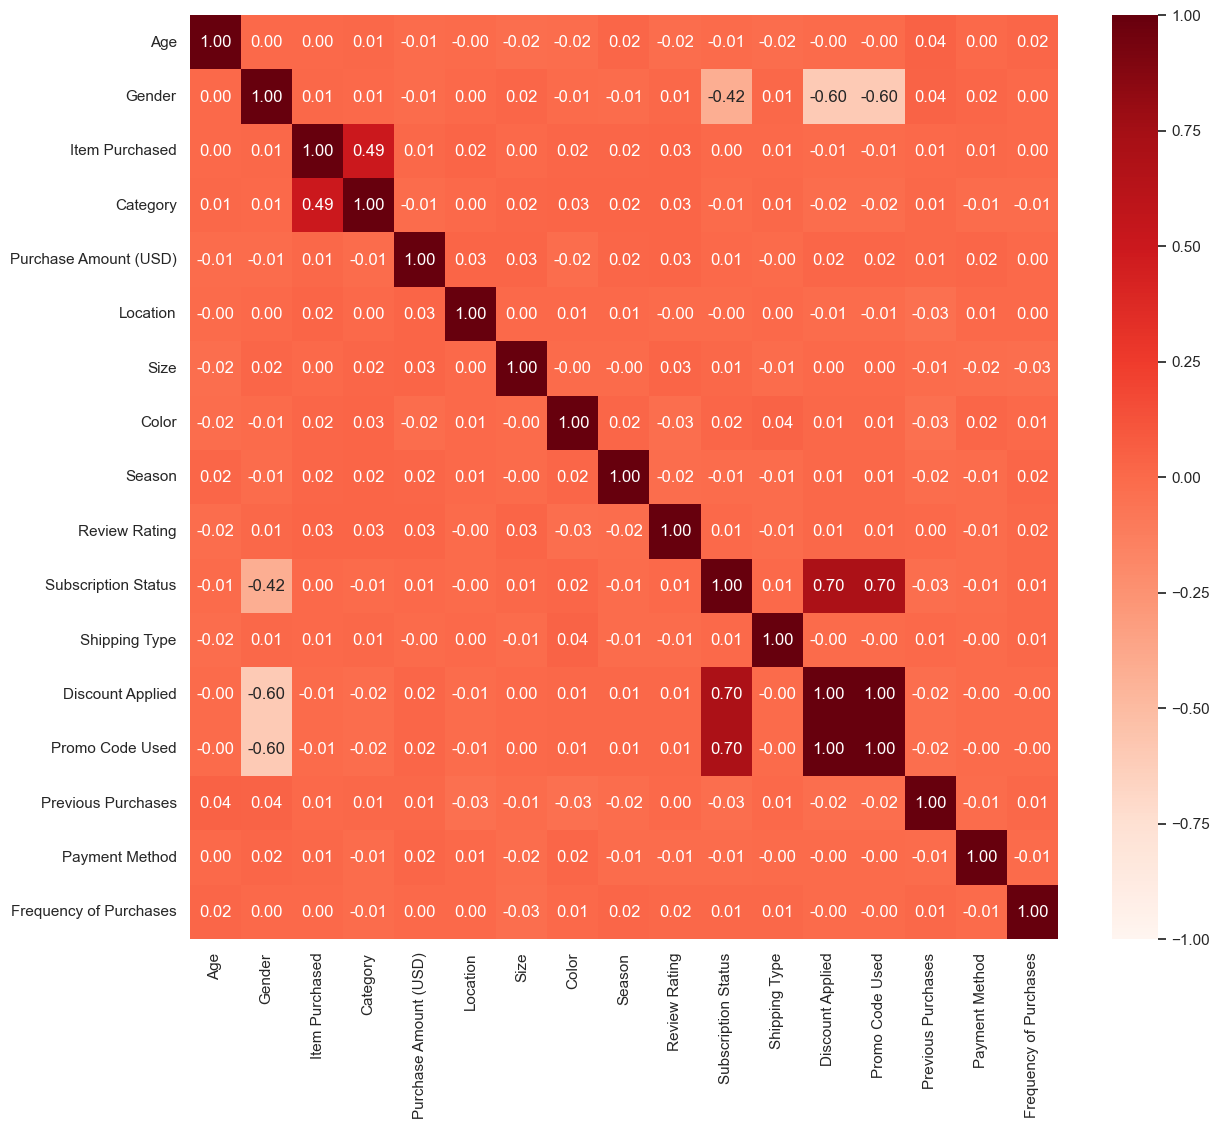

In [74]:
plt.figure(figsize =(14,12))
sns.heatmap(data=shopping_corr,annot=True,cmap ="Reds",fmt=".2f",vmin=-1,vmax=1);

0. Sự phân phối của giới tính và độ tuổi của khách hàng

In [75]:
import plotly.express as px

In [76]:
#Count of customer on the basis of age
GA=df.groupby('Gender')[['Gender','Age']].value_counts().sort_values(ascending=False).reset_index()
fig=px.scatter(GA,x='Age',y='count',color='Gender',size='count')
fig.show()

1. Average Customer Purchase amount by State

How is the distribution of purchase amounts across states? What state has the lowest purchase amount, and which state tends to make higher purchases?

In [77]:
# Extract the 'Location' and 'Purchase Amount (USD)' columns from the DataFrame
df_spatial = df[['Location', 'Purchase Amount (USD)']]

# Group by 'Location' and calculate the median purchase amount for each location
df_spatial = df_spatial.groupby('Location').median()

# Reset the index and rename the 'Purchase Amount (USD)' column
df_spatial = df_spatial.reset_index().rename(columns={"Purchase Amount (USD)": "Median Purchase Amount (USD)"})

# Mapping state names to their respective two-letter codes
code = {'Alabama': 'AL',
        'Alaska': 'AK',
        'Arizona': 'AZ',
        'Arkansas': 'AR',
        'California': 'CA',
        'Colorado': 'CO',
        'Connecticut': 'CT',
        'Delaware': 'DE',
        'District of Columbia': 'DC',
        'Florida': 'FL',
        'Georgia': 'GA',
        'Hawaii': 'HI',
        'Idaho': 'ID',
        'Illinois': 'IL',
        'Indiana': 'IN',
               'Iowa': 'IA',
        'Kansas': 'KS',
        'Kentucky': 'KY',
        'Louisiana': 'LA',
        'Maine': 'ME',
        'Maryland': 'MD',
        'Massachusetts': 'MA',
        'Michigan': 'MI',
        'Minnesota': 'MN',
        'Mississippi': 'MS',
        'Missouri': 'MO',
        'Montana': 'MT',
        'Nebraska': 'NE',
        'Nevada': 'NV',
        'New Hampshire': 'NH',
        'New Jersey': 'NJ',
        'New Mexico': 'NM',
        'New York': 'NY',
        'North Carolina': 'NC',
        'North Dakota': 'ND',
        'Ohio': 'OH',
        'Oklahoma': 'OK',
        'Oregon': 'OR',
        'Pennsylvania': 'PA',
        'Rhode Island': 'RI',
        'South Carolina': 'SC',
        'South Dakota': 'SD',
        'Tennessee': 'TN',
        'Texas': 'TX',
        'Utah': 'UT',
        'Vermont': 'VT',
        'Virginia': 'VA',
        'Washington': 'WA',
        'West Virginia': 'WV',
        'Wisconsin': 'WI',
        'Wyoming': 'WY'}
        # Create a new column 'Code' by mapping the 'Location' column to the state codes
df_spatial['Code'] = df_spatial['Location'].map(code)

In [78]:
# Assuming 'df_spatial' is a pandas DataFrame and 'px' is Plotly Express
# Create a choropleth map using Plotly Express to visualize median purchase amounts by state
fig = px.choropleth(
    df_spatial,
    locations='Code',  # Specify the state codes for locations
    color='Median Purchase Amount (USD)',  # Use median purchase amount for coloring
    color_continuous_scale='spectral_r',  # Choose a color scale
    hover_name='Location',  # Display location names on hover
    locationmode='USA-states',  # Set the location mode to 'USA-states'
    labels={'Median Purchase Amount (USD)': 'Median Purchase Amount (USD)'},  # Label for color legend
    scope='usa'  # Set the map scope to 'usa'
)

# Add text labels for state codes using scattergeo
fig.add_scattergeo(
    locations=df_spatial['Code'],
    locationmode='USA-states',
    text=df_spatial['Code'],
    mode='text'
)
# Update layout properties such as title
fig.update_layout(
    title={
        'text': 'Avg. Customer Purchase Amount by State',
        'xanchor': 'center',
        'yanchor': 'top',
        'x': 0.5
    }
)

# Show the interactive plot with specified height and width
fig.show(height=700, width=1400)

2. Analysis of seasonal trends in purchases

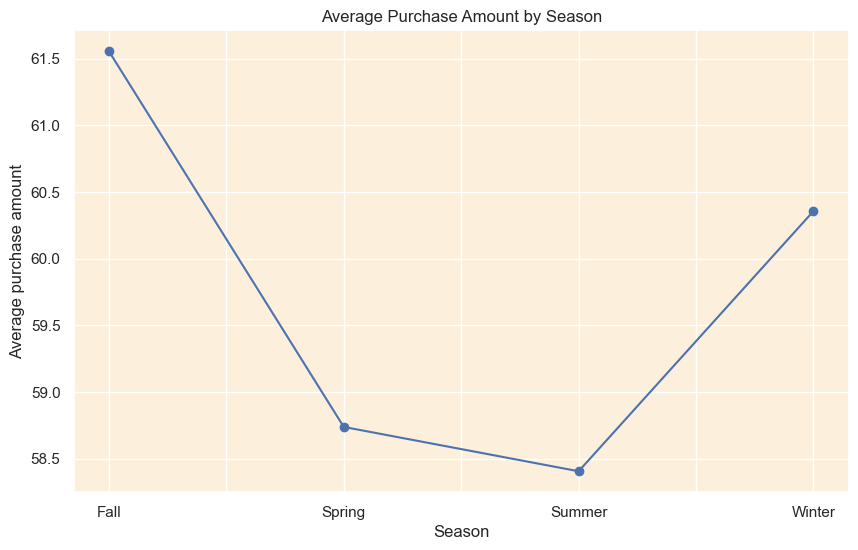

<Figure size 640x480 with 0 Axes>

In [79]:

seasonal_purchase_amount = df.groupby('Season')['Purchase Amount (USD)'].mean()
plt.figure(figsize=(10, 6))
seasonal_purchase_amount.plot(kind='line', marker='o')
plt.title('Average Purchase Amount by Season')
plt.xlabel('Season')
plt.ylabel('Average purchase amount')
plt.show()
plt.savefig(' seasonal trends in purchases')

3. Sự khác nhau giữa nam và nữ  theo độ tuổi khi mua hàng như thế nào
=> phần này t muốn chuyển thành biểu đồ đường hoặc biểu đồ cột nhuwg gộp MALE và FEMALE vào chung 1 bảng thoi

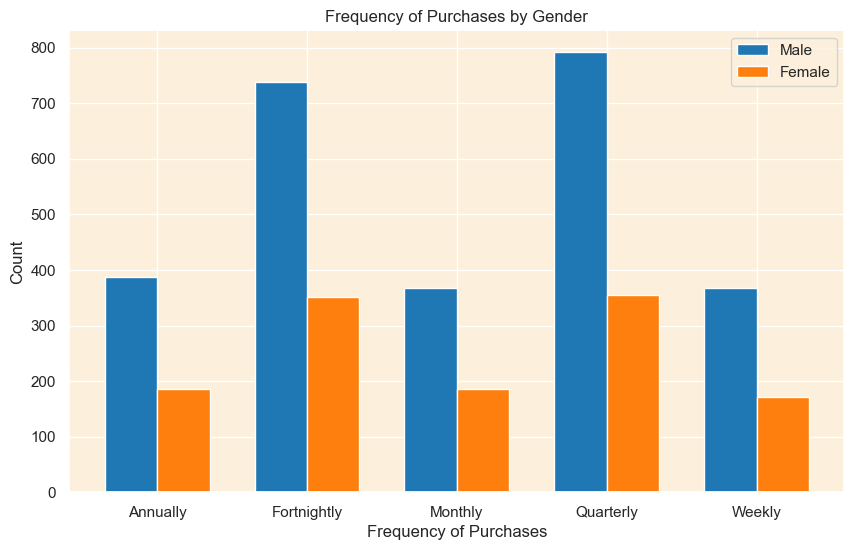

In [80]:
# Grouping by 'Gender' and 'Frequency of Purchases'
grouped_gender = df.groupby(['Gender', 'Frequency of Purchases'])

# Counting the occurrences of each item purchased for each gender and frequency
R = grouped_gender.size().reset_index(name='Count')

# Creating a bar plot using matplotlib
fig, ax = plt.subplots(figsize=(10, 6))

# Define the x locations for the groups
x = np.arange(len(R['Frequency of Purchases'].unique()))

# Define the width of the bars
width = 0.35

# Plot the bars for each gender
ax.bar(x - width/2, R[R['Gender'] == 'Male']['Count'], width, label='Male', color='#1f77b4')
ax.bar(x + width/2, R[R['Gender'] == 'Female']['Count'], width, label='Female', color='#ff7f0e')

# Customizing the plot
ax.set_title('Frequency of Purchases by Gender')
ax.set_xlabel('Frequency of Purchases')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(R['Frequency of Purchases'].unique())
ax.legend()

# Displaying the plot
plt.show()

4. Có mối liên hệ nào giữa độ tuổi của khách hàng và số tiền họ bỏ ra khi mua hàng không? Có nhóm tuổi nào có xu hướng chi tiêu nhiều hơn hoặc ít hơn những nhóm tuổi khác không?

In [81]:
# Trục X (Horizontal Axis): Độ tuổi của khách hàng ("Age"). Đây là biến độc lập, thường được dùng để xem liệu có mối quan hệ nào giữa tuổi và các yếu tố khác không.
# Trục Y (Vertical Axis): Số tiền mua hàng ("Purchase Amount"). Đây là biến phụ thuộc mà bạn muốn phân tích xem nó thay đổi như thế nào tùy theo độ tuổi của khách hàng.

In [82]:
# Kích Thước Bong Bóng: Số lần mua trước đó ("Previous Purchases"). Kích thước của mỗi bong bóng sẽ đại diện cho số lần mua trước đó của khách hàng, giúp hiển thị mức độ thường xuyên mua hàng của họ. Bong bóng lớn hơn cho thấy số lần mua nhiều hơn.

# **STEP3: K - CLUSTERING**

K-Means is an unsupervised machine learning algorithm that clusters data into a specified number of groups (K) by minimizing the within-cluster sum-of-squares (WCSS), also known as inertia. The algorithm iteratively assigns each data point to the nearest centroid, then updates the centroids by calculating the mean of all assigned points. The process repeats until convergence or a stopping criterion is reached.

In [83]:
# Select relevant columns for segmentation
df_segments = df[["Age", "Gender", "Purchase Amount (USD)", "Frequency of Purchases"]]

# Use one-hot encoding for categorical columns 'Gender' and 'Frequency of Purchases'
df_segments = pd.get_dummies(df_segments, columns=['Gender', 'Frequency of Purchases'], drop_first=True, dtype=int)

# Display the first few rows of the resulting DataFrame
df_segments.head()

,Age,Purchase Amount (USD),Gender_Male,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,55,53,1,1,0,0,0
1,19,64,1,1,0,0,0
2,50,73,1,0,0,0,1
3,21,90,1,0,0,0,1
4,45,49,1,0,0,0,0


**Elbow Method**

The Elbow Method is a technique for identifying the ideal number of clusters in a dataset. It involves iterating through the data, generating clusters for various values of k. The k-means algorithm calculates the sum of squared distances between each data point and its assigned cluster centroid, known as the inertia or WCSS score. By plotting the inertia score against the k value, we create a graph that typically exhibits an elbow shape, hence the name "Elbow Method". The elbow point represents the k-value where the reduction in inertia achieved by increasing k becomes negligible, indicating the optimal stopping point for the number of clusters.

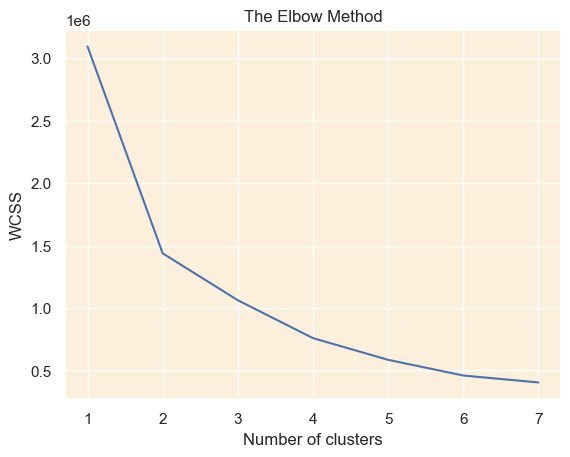

In [84]:
# Initialize an empty list to store the Within-Cluster-Sum-of-Squares (WCSS) for different cluster numbers
wcss = []

# Iterate over different numbers of clusters to find the optimal number
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i)  # Create a KMeans instance with the current number of clusters
    kmeans.fit(df_segments)  # Fit the model to the data
    wcss_iter = kmeans.inertia_  # Get the WCSS for the current number of clusters
    wcss.append(wcss_iter)  # Append the WCSS to the list

# Create a line plot to visualize the Elbow Method
number_clusters = range(1, 8)
plt.plot(number_clusters, wcss)
plt.title('The Elbow Method')  # Set the title of the plot
plt.xlabel('Number of clusters')  # Set the label for the X-axis
plt.ylabel('WCSS')  # Set the label for the Y-axis

# Display the plot
plt.show()

Optimal k Value: Elbow Method Insights
The optimal value of k for the KMeans clustering algorithm can be found at the elbow point. Using the YellowBrick library for the Elbow method, we observe that the suggested optimal k value is 3

In [85]:
# Create a KMeans instance with the desired number of clusters (in this case, 3)
kmeans = KMeans(n_clusters=3)

# Fit the KMeans model to the data and obtain cluster labels
kmeans.fit(df_segments)
cluster_labels = kmeans.predict(df_segments)

# Assign the cluster labels to a new column 'Clusters' in the DataFrame
df_segments['Clusters'] = cluster_labels

# Display the DataFrame with the added 'Clusters' column
df_segments

,Age,Purchase Amount (USD),Gender_Male,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly,Clusters
0,55,53,1,1,0,0,0,0
1,19,64,1,1,0,0,0,2
2,50,73,1,0,0,0,1,1
3,21,90,1,0,0,0,1,2
4,45,49,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
3895,40,28,0,0,0,0,1,0
3896,52,49,0,1,0,0,0,0
3897,46,33,0,0,0,1,0,0
3898,44,77,0,0,0,0,1,1
